This will be formatted in a manner to show my thought process, rather than to be professional.

In [1]:
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('Trans Risk.ods', usecols='A:V')
df.head()

,State,Transgender Risk,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,...,Legislative Control,Governor Party,State Party,Total Court,Length of term,Mandatory Retirement Age,Court Control,President 2024,Population 2025,Transgender Population 2016
0,Alabama,Y,105,29,76,NaN,NaN,35,8,27,...,R,R,R,9,6 years,70.0,Republican,R,5193088,22500
1,Alaska,N,40,14,21,5.0,NaN,20,9,11,...,R,R,R,5,10 years,70.0,Republican,R,737270,2700
2,Arizona,N,60,27,33,NaN,NaN,30,13,17,...,R,D,S,7,6 years,70.0,Republican,R,7623818,30550
3,Arkansas,Y,100,19,80,NaN,1.0,35,6,28,...,R,R,R,7,8 years,NaN,Republican,R,3114791,13400
4,California,N,80,60,20,NaN,NaN,40,30,10,...,D,D,D,7,12 years,NaN,Democratic,D,39355309,218400


The data here was compiled by me so it's already mostly clean

In [3]:
# Making sure all 50 states are here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   State                        50 non-null     object 
 1   Transgender Risk             50 non-null     object 
 2   Total House                  50 non-null     int64  
 3   House Dem                    50 non-null     int64  
 4   House Rep                    50 non-null     int64  
 5   House Third Party            8 non-null      float64
 6   House Vacancies              13 non-null     float64
 7   Total Senate                 50 non-null     int64  
 8   Senate Dem                   50 non-null     int64  
 9   Senate Rep                   50 non-null     int64  
 10  Senate Third Party           5 non-null      float64
 11  Senate Vacancies             6 non-null      float64
 12  Legislative Control          50 non-null     object 
 13  Governor Party        

In [4]:
# All the nulls can be filled safely here; retirement age's NaNs are because there is no limit, State Party's is from Nebraska importing weirdly, and the rest are because they should be 0
df['Mandatory Retirement Age'] = df['Mandatory Retirement Age'].fillna(999)
df['State Party'] = df['State Party'].fillna('N/A')
df.fillna(0, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   State                        50 non-null     object 
 1   Transgender Risk             50 non-null     object 
 2   Total House                  50 non-null     int64  
 3   House Dem                    50 non-null     int64  
 4   House Rep                    50 non-null     int64  
 5   House Third Party            50 non-null     float64
 6   House Vacancies              50 non-null     float64
 7   Total Senate                 50 non-null     int64  
 8   Senate Dem                   50 non-null     int64  
 9   Senate Rep                   50 non-null     int64  
 10  Senate Third Party           50 non-null     float64
 11  Senate Vacancies             50 non-null     float64
 12  Legislative Control          50 non-null     object 
 13  Governor Party        

In [ ]:
df_dummied = pd.get_dummies(df, columns=['Legislative Control', 'Governor Party', 'State Party', 'Length of term', 'Court Control', 'President 2024', 'Transgender Risk']) # Realizing after that I could've just dropped state and then left this blank
df_dummied.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,...,Length of term_Until 70 years of age,Length of term_Until retirement or the age of 70,Court Control_Democratic,Court Control_Republican,Court Control_Split,President 2024_D,President 2024_R,President 2024_Split,Transgender Risk_N,Transgender Risk_Y
0,Alabama,105,29,76,0.0,0.0,35,8,27,0.0,...,False,False,False,True,False,False,True,False,False,True
1,Alaska,40,14,21,5.0,0.0,20,9,11,0.0,...,False,False,False,True,False,False,True,False,True,False
2,Arizona,60,27,33,0.0,0.0,30,13,17,0.0,...,False,False,False,True,False,False,True,False,True,False
3,Arkansas,100,19,80,0.0,1.0,35,6,28,0.0,...,False,False,False,True,False,False,True,False,False,True
4,California,80,60,20,0.0,0.0,40,30,10,0.0,...,False,False,True,False,False,True,False,False,True,False


Our dependent variable here will be Transgender Risk. Let's split it and take a look at our distribution

In [6]:
y = df_dummied['Transgender Risk_N']
X = df_dummied.drop(['Transgender Risk_N', 'Transgender Risk_Y', 'State'], axis=1)
y.value_counts() # Y means there is high or greater risk

Transgender Risk_N
True     26
False    24
Name: count, dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=19)

I'll be using a decision tree for this project

In [8]:
first_tree = tree.DecisionTreeClassifier()
first_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

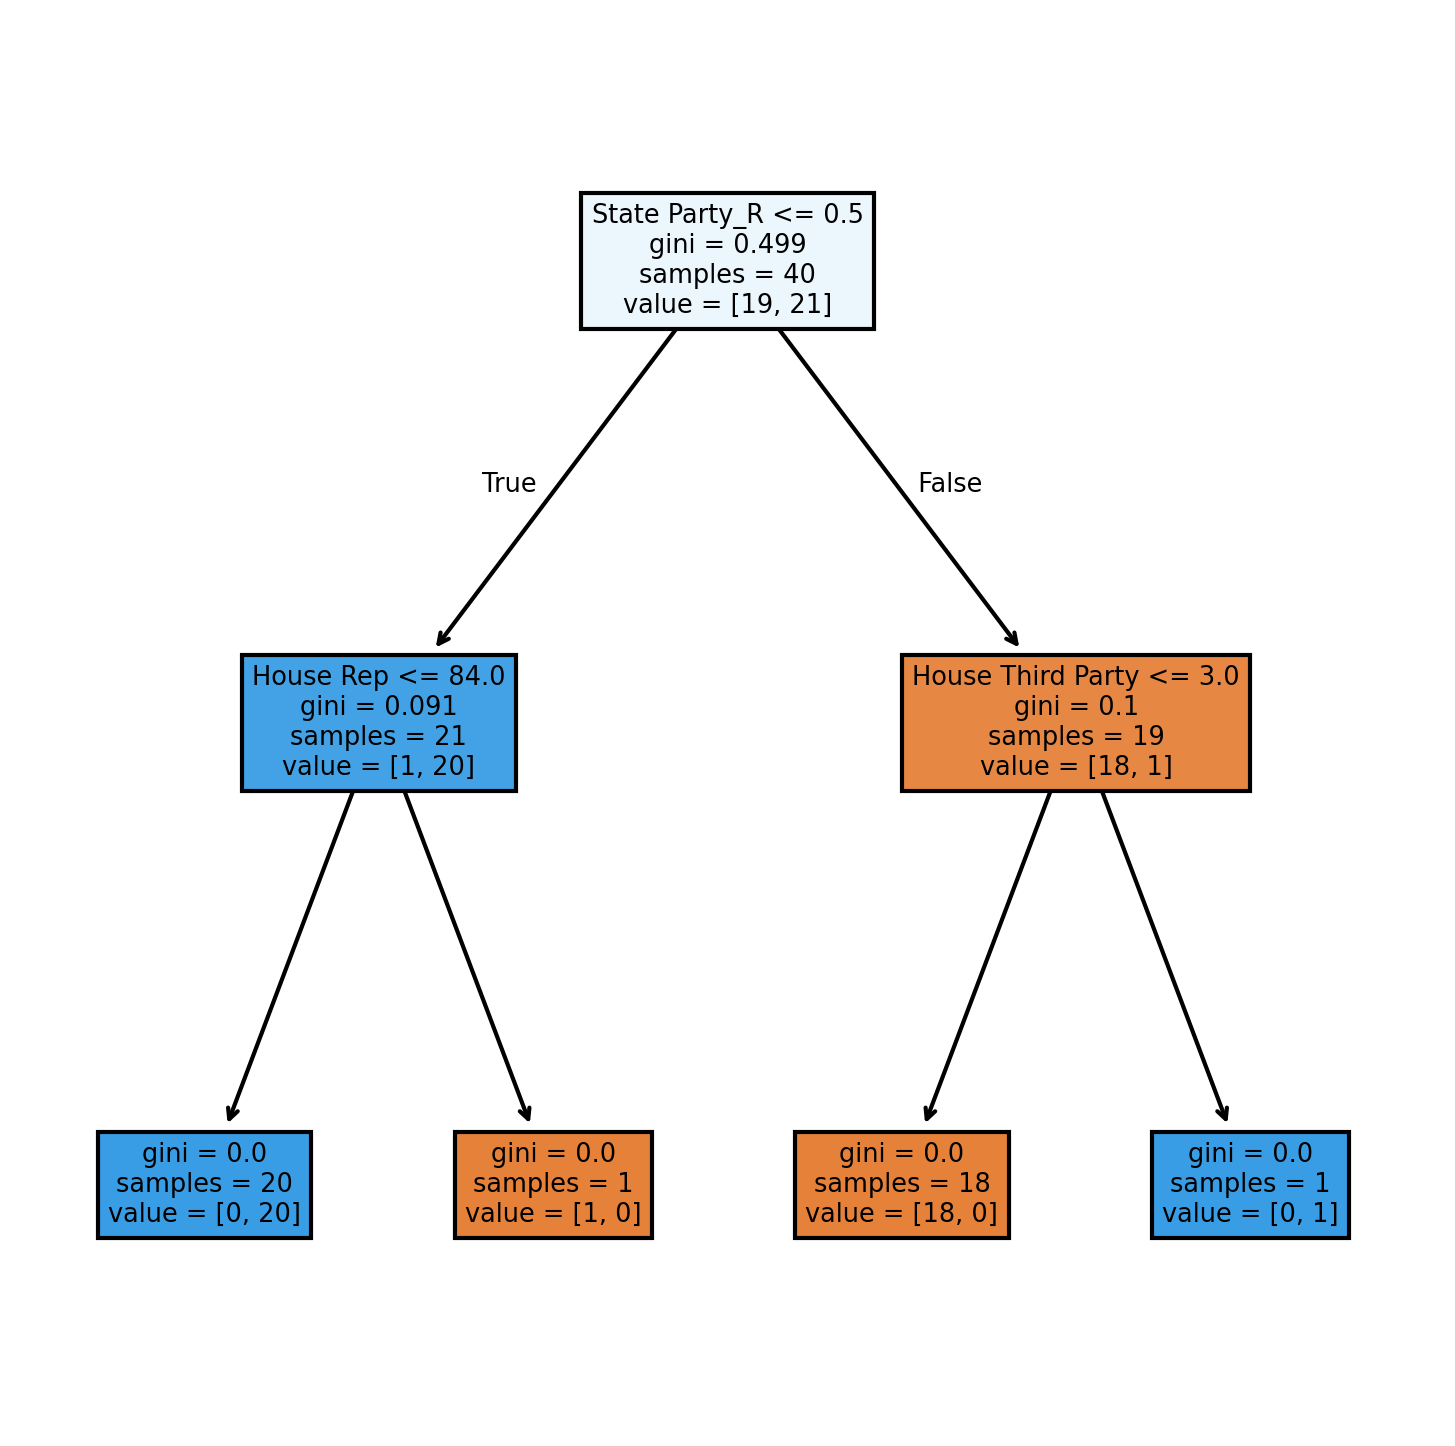

In [9]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (6,6), dpi=300)
tree.plot_tree(first_tree, max_depth = 3, feature_names = X.columns, filled=True)
plt.show()

An interesting, albeit underwhelming, result. Let's see how it did with the test data.

In [10]:
first_tree.score(X_test, y_test)

0.8

That's not too bad. Unfortunately with a sample size this small it'll be easy for the model to take shortcuts. Let's get a litte more particular with the measured variables.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   State                        50 non-null     object 
 1   Transgender Risk             50 non-null     object 
 2   Total House                  50 non-null     int64  
 3   House Dem                    50 non-null     int64  
 4   House Rep                    50 non-null     int64  
 5   House Third Party            50 non-null     float64
 6   House Vacancies              50 non-null     float64
 7   Total Senate                 50 non-null     int64  
 8   Senate Dem                   50 non-null     int64  
 9   Senate Rep                   50 non-null     int64  
 10  Senate Third Party           50 non-null     float64
 11  Senate Vacancies             50 non-null     float64
 12  Legislative Control          50 non-null     object 
 13  Governor Party        

In [12]:
df_simple = df[['Transgender Risk', 'Legislative Control','Governor Party', 'State Party', 'Court Control', 'President 2024', 'Population 2025', 'Transgender Population 2016']]

In [13]:
dummied_2 = pd.get_dummies(df_simple)

In [14]:
X_2 = dummied_2.drop(['Transgender Risk_Y', 'Transgender Risk_N'], axis=1)
y_2 = dummied_2['Transgender Risk_N']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_2, y_2, test_size=.2, random_state=64)

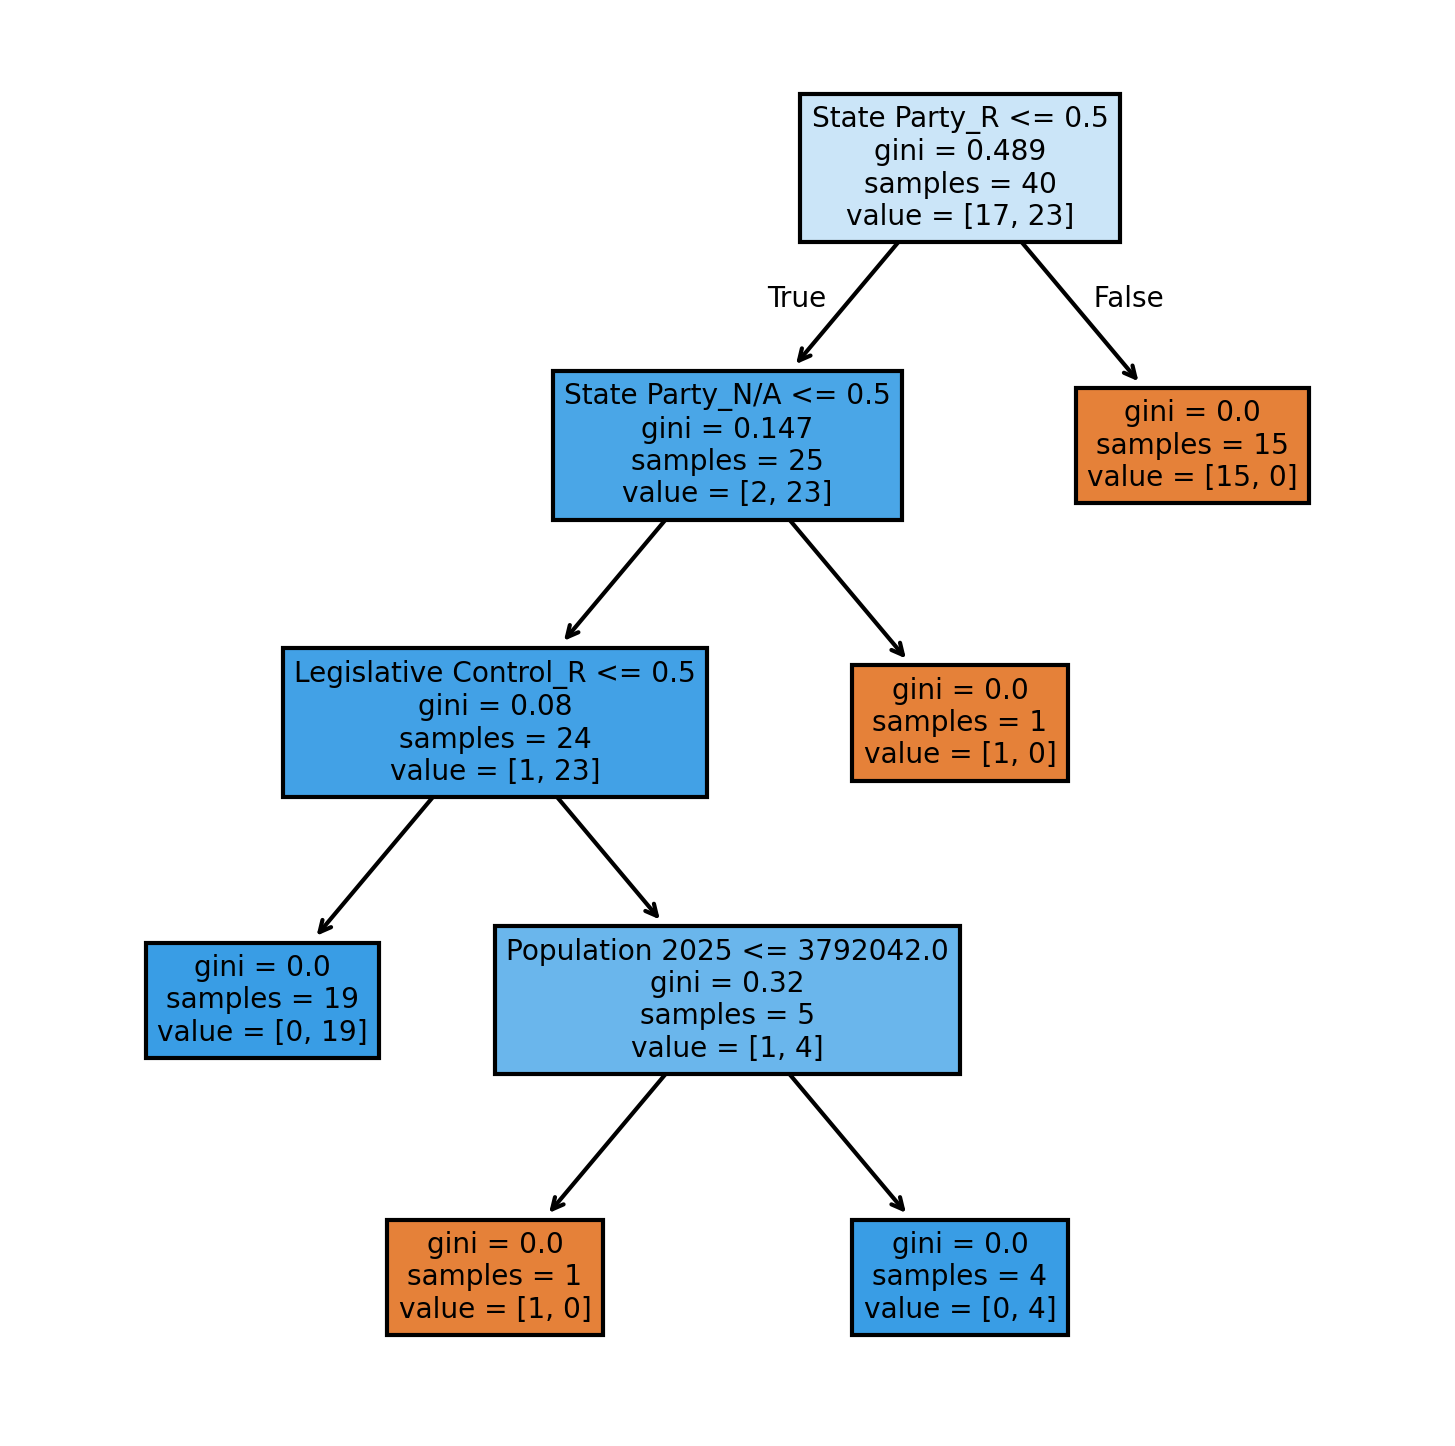

In [16]:
tree_2 = tree.DecisionTreeClassifier()
tree_2.fit(X_train, y_train)
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (6,6), dpi=300)
tree.plot_tree(tree_2, feature_names = X_2.columns, filled=True)
plt.show()

This one lends to some more interesting analysis; for the states with a Republican legislature but not governor, only the state with the smallest population population remains risky. Let's see how the tree fares

In [17]:
tree_2.score(X_test, y_test)

0.9

Okay, so removing those variables lended to a more accurate tree. But I don't trust a lone tree when I have a low sample size. Now to try some forests

In [18]:
from sklearn.model_selection import cross_val_score
import numpy as np

In [19]:
first_cross = cross_val_score(first_tree, X, y, cv=10)
print(first_cross)
print(np.average(first_cross))

[0.8 1.  0.8 1.  0.6 1.  0.8 1.  0.6 1. ]
0.86


In [20]:
cross_2 = cross_val_score(tree_2, X_2, y_2, cv=10)
print(cross_2)
print(np.average(cross_2))

[0.8 1.  0.8 1.  0.8 1.  0.6 1.  1.  0.6]
0.86


In case the kernel gets reset, the first tree recieved an average accuracy of .86, while the second got .8800. Certainly seems like removing those extra variables lead to a more consistently correct tree

I still feel that I'd like the tree to be more descriptive. State Party seems to be very important for descisions but it's basically a summary of two other variables, so I'll try removing that while also tweaking the tree's parameters. Transgender Population is also essentially correlated with Population, so I'll remove that too.

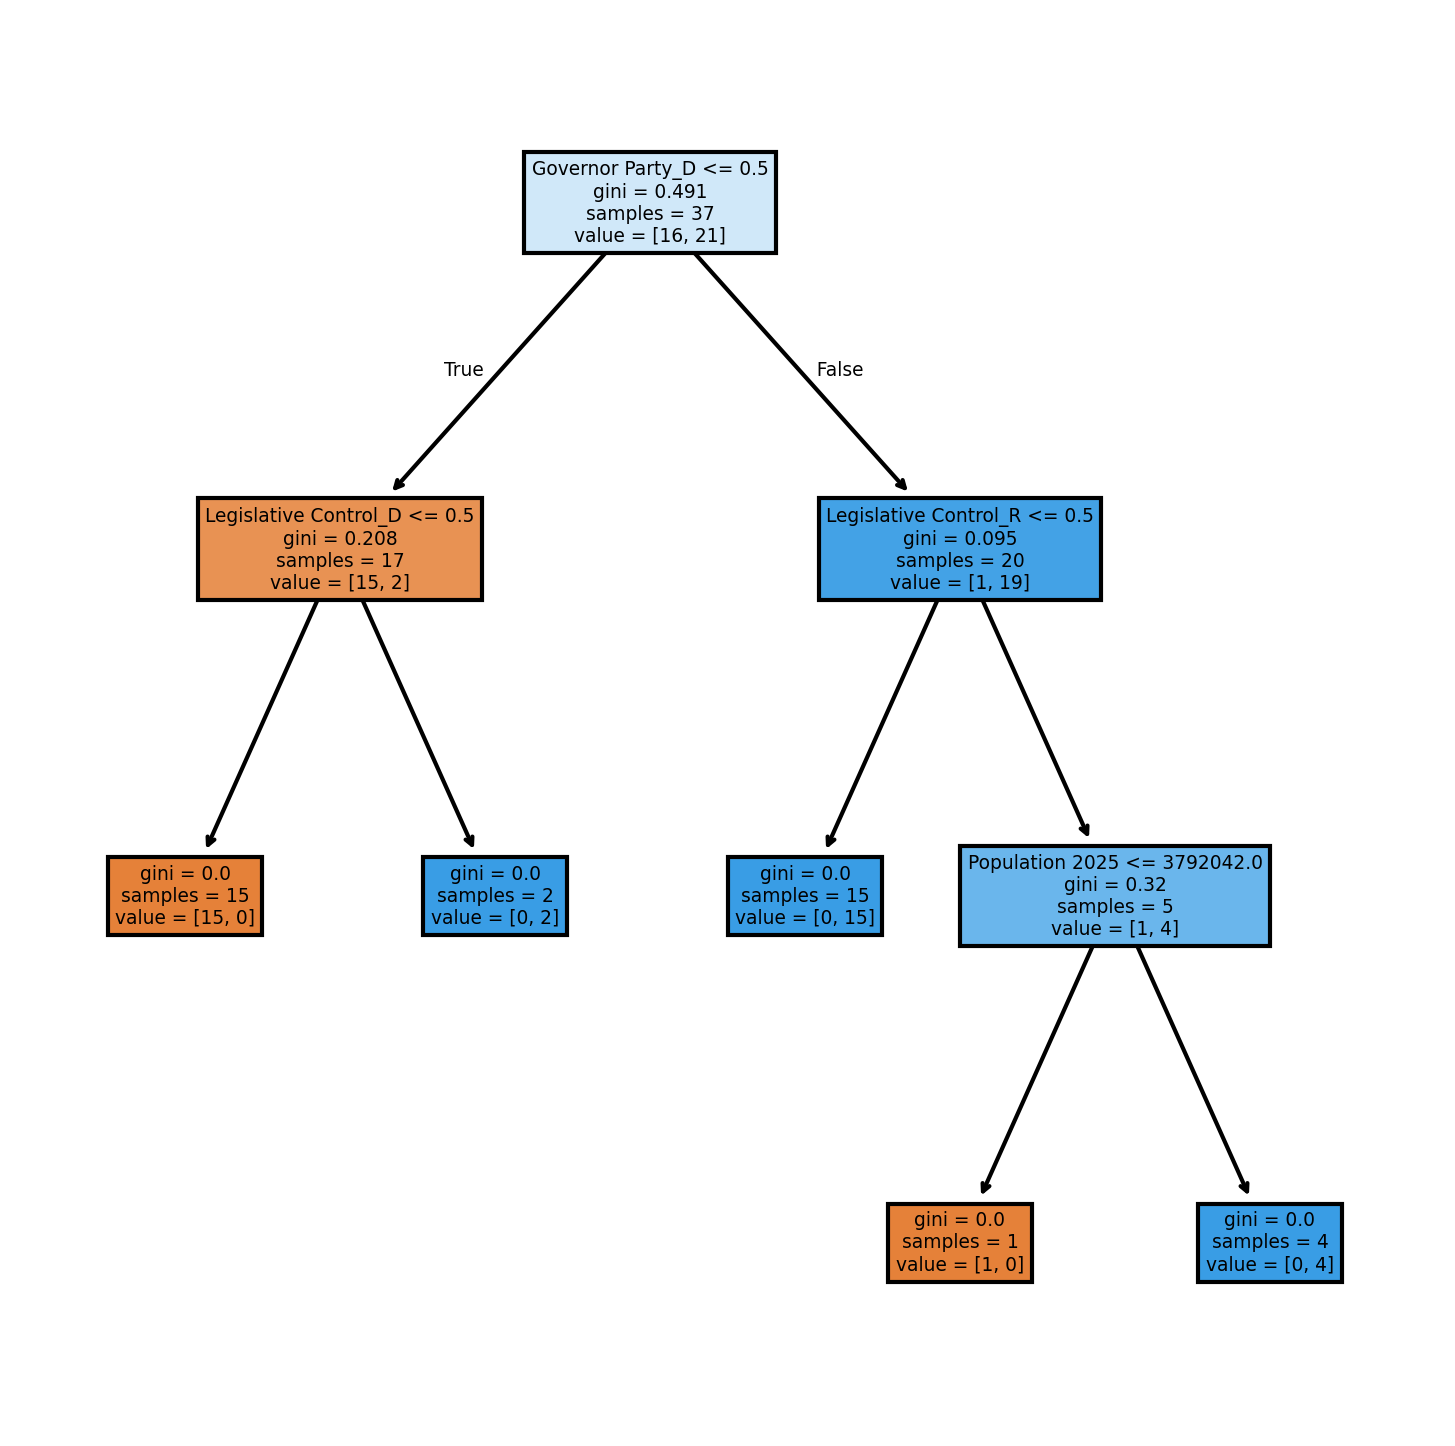

In [ ]:
df_simpler = df_simple.drop(['State Party', 'Transgender Population 2016'], axis=1)
dummied_3 = pd.get_dummies(df_simpler)
X_3 = dummied_3.drop(['Transgender Risk_Y', 'Transgender Risk_N'], axis=1)
y_3 = dummied_3['Transgender Risk_N']
X_train, X_test, y_train, y_test = train_test_split(X_3, y_3, test_size=.25, random_state=66) # Slightly higher test pool this time
tree_3 = tree.DecisionTreeClassifier(min)
tree_3.fit(X_train, y_train)
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (6,6), dpi=300)
tree.plot_tree(tree_3, feature_names = X_3.columns, filled=True)
plt.show()

Oooh okay, this is a lot more interesting of a tree. Now let's see it's accuracy by itself, and the cv

In [38]:
tree_3.score(X_test, y_test)

0.9230769230769231

In [39]:
cross_3 = cross_val_score(tree_3, X_3, y_3, cv=10)
print(cross_3)
print(np.average(cross_3))

[0.8 1.  0.8 1.  0.8 0.8 0.8 1.  1.  0.6]
0.86


And just as accurate as the first tree...